ractice training a deep neural network on the CIFAR10 image dataset:
a. Build a DNN with 20 hidden layers of 100 neurons each (that’s too many, but
it’s the point of this exercise). Use He initialization and the ELU activation
function.
b. Using Nadam optimization and early stopping, train the network on the
CIFAR10 dataset. You can load it with keras.datasets.cifar10.load_
data(). The dataset is composed of 60,000 32 × 32–pixel color images (50,000
for training, 10,000 for testing) with 10 classes, so you’ll need a softmax out‐
put layer with 10 neurons. Remember to search for the right learning rate each
time you change the model’s architecture or hyperparameters.
c. Now try adding Batch Normalization and compare the learning curves: Is it
converging faster than before? Does it produce a better model? How does it
affect training speed?
d. Try replacing Batch Normalization with SELU, and make the necessary adjust‐
ements to ensure the network self-normalizes (i.e., standardize the input fea‐
tures, use LeCun normal initialization, make sure the DNN contains only a
sequence of dense layers, etc.).
e. Try regularizing the model with alpha dropout. Then, without retraining your
model, see if you can achieve better accuracy using MC Dropout.
f. Retrain your model using 1cycle scheduling and see if it improves training
speed and model accuracy.

In [27]:
# a.)
# Constructing the model
from tensorflow.keras import layers, models

model=models.Sequential([layers.Input(shape=(32,32,3)), layers.Flatten()])

for _ in range(20):
    model.add(layers.Dense(100, activation='elu', kernel_initializer='he_normal'))

model.add(layers.Dense(10, activation='softmax'))
    
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       307,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,210 (1.91 MB)

 Trainable params: 500,210 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

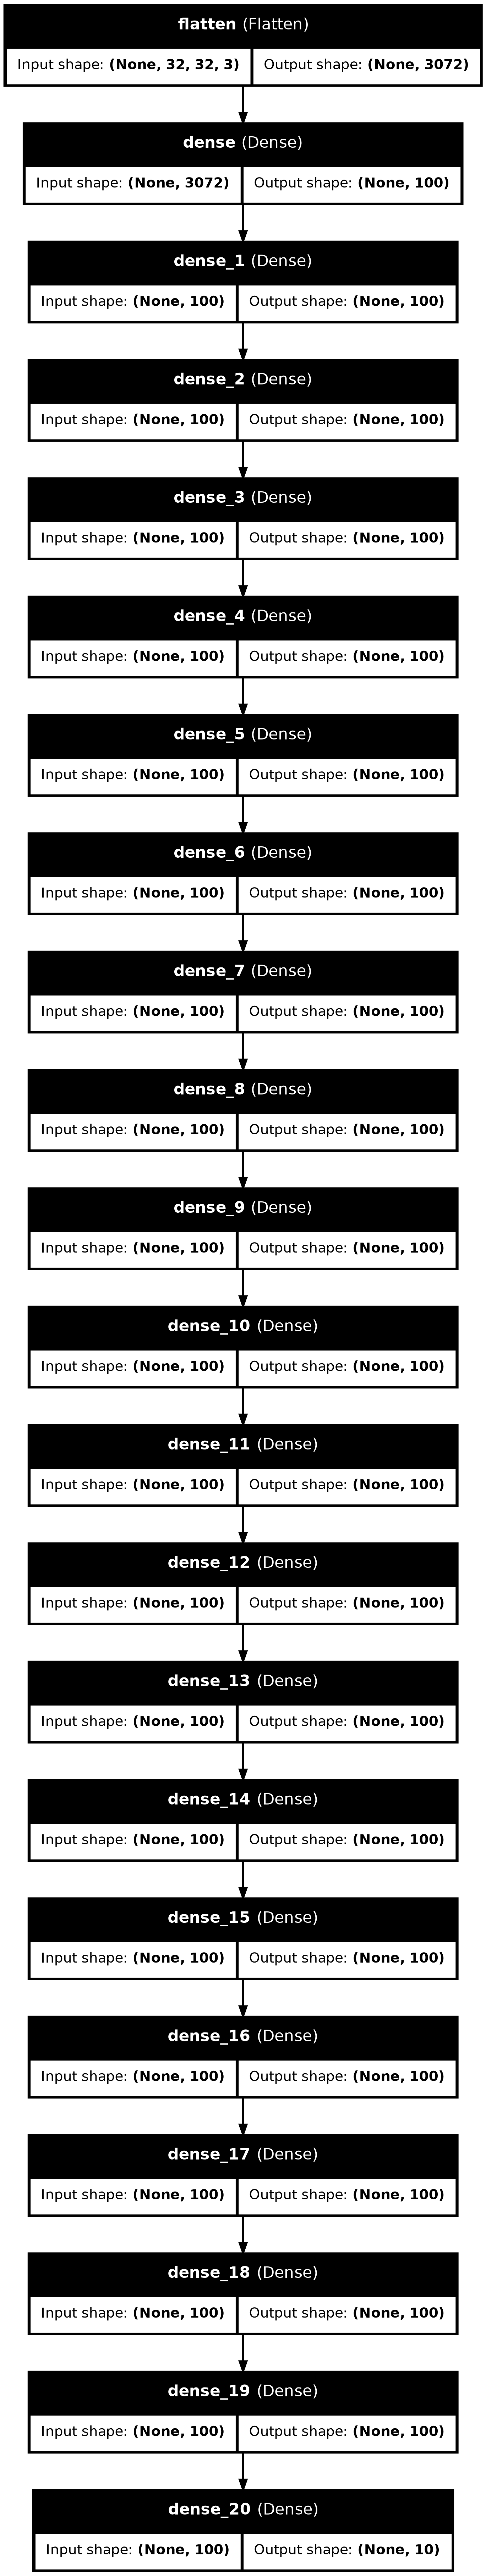

In [28]:
#Plotting the model
from tensorflow.keras.utils import plot_model

plot_model(model, show_shapes=True, show_layer_names=True)

In [32]:
# Load the dataset

from tensorflow.keras.datasets import cifar10

# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

# Preprocessing the data: normalize images
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Keep labels as integers for sparse categorical crossentropy
# No need to convert to one-hot
print("After preprocessing:")
print("Training labels shape (should be integers):", y_train.shape)
print("Testing labels shape (should be integers):", y_test.shape)



/home/daniel/Documents/DEEP LEARNING/deep_learning/venv/lib/python3.13/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)
After preprocessing:
Training labels shape (should be integers): (50000, 1)
Testing labels shape (should be integers): (10000, 1)


Stopping early, loss exploded.


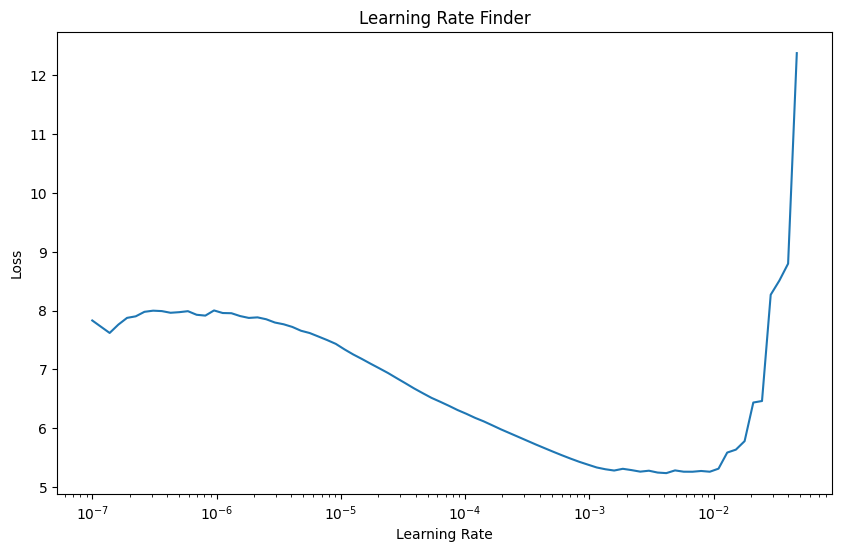

Suggested learning rate: 0.004168693834703355


In [33]:
# Search for the right learning rate

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Nadam
from tensorflow import keras

keras.backend.clear_session()  # Clear previous models from memory
np.random.seed(42)

# Learning rate search
class LRFinder:
    def __init__(self, model):
        self.model = model
        self.lrs = []
        self.losses = []
    
    def on_batch_end(self, batch, logs=None):
        logs = logs or {}
        self.losses.append(logs.get('loss'))
        self.lrs.append(self.lr)
    
    def find(self, X_train, y_train, min_lr=1e-7, max_lr=1, num_batches=100, batch_size=128):
        num_batches = min(num_batches, len(X_train) // batch_size)
        step_size = (np.log(max_lr) - np.log(min_lr)) / num_batches
        
        # Compile with initial learning rate    
        self.model.compile(optimizer=Nadam(learning_rate=min_lr), 
                          loss='sparse_categorical_crossentropy', 
                          metrics=['accuracy'])
        
        self.lr = min_lr
        
        for batch in range(num_batches):
            batch_start = batch * batch_size
            batch_end = min(batch_start + batch_size, len(X_train))
            X_batch = X_train[batch_start:batch_end]
            y_batch = y_train[batch_start:batch_end]
            
            # Update learning rate
            self.lr = min_lr * np.exp(step_size * batch)
            self.model.optimizer.learning_rate.assign(self.lr)
            
            # Train on batch
            logs = self.model.train_on_batch(X_batch, y_batch)

            loss = logs[0]
            self.on_batch_end(batch, {'loss': loss})

            # Stop if loss becomes NaN or extremely large; Sometimes LR finder crashes when loss explodes. Add a stop condition:
            if np.isnan(loss) or loss > 10:
                print("Stopping early, loss exploded.")
                break
        
        return self.lrs, self.losses
    
    def plot(self):
        plt.figure(figsize=(10, 6))
        plt.xscale('log')
        plt.plot(self.lrs, self.losses)
        plt.xlabel('Learning Rate')
        plt.ylabel('Loss')
        plt.title('Learning Rate Finder')
        plt.show()

# Run the learning rate finder
lr_finder = LRFinder(model)
lrs, losses = lr_finder.find(X_train, y_train, min_lr=1e-7, max_lr=1, num_batches=100)
lr_finder.plot()

# Recommended learning rate: Look for steepest negative slope
best_lr = lrs[np.argmin(losses)]
print(f"Suggested learning rate: {best_lr}")

In [34]:
# Compile the model with the optimal learning rate
model.compile(optimizer=Nadam(learning_rate=best_lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [35]:
#Early stopping

from tensorflow import keras


early_stop= keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [36]:
# Train the model
model.fit(X_train, y_train, epochs=20, batch_size=128, validation_data=(X_test, y_test), callbacks=[early_stop])

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 78s 78ms/step - accuracy: 0.1875 - loss: 23.9121 - val_accuracy: 0.2091 - val_loss: 2.0368
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.2168 - loss: 2.0387 - val_accuracy: 0.2196 - val_loss: 2.0101
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.2211 - loss: 2.0252 - val_accuracy: 0.2340 - val_loss: 1.9921
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 80ms/step - accuracy: 0.2284 - loss: 2.0047 - val_accuracy: 0.2482 - val_loss: 1.9690
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.2494 - loss: 1.9575 - val_accuracy: 0.2679 - val_loss: 1.9189
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.2715 - loss: 1.9094 - val_accuracy: 0.2876 - val_loss: 1.8829
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.2857 - loss: 1.8881 - val_accuracy: 0.2934 - val_loss: 1.8660
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 80ms/step - accuracy: 0.2898 - loss: 1.8768 -

In [37]:
# Question c. Adding Batch Normalization 
import tensorflow as tf

keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

model=models.Sequential([layers.Input(shape=(32,32,3)), layers.Flatten()])

model.add(layers.BatchNormalization())

for _ in range(20):
    model.add(layers.Dense(100, kernel_initializer='he_normal'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('elu'))
    
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer=Nadam(learning_rate=best_lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)



In [38]:
#Define callbacks
import os


model_checkpoint_cb = keras.callbacks.ModelCheckpoint('my_best_cifar10_model.h5', save_best_only=True, monitor='val_loss')
run_index = 1
run_log_dir =  os.path.join(os.curdir, "my_cifar10_logs", "run_{:03d}".format(run_index))
tensorboard_cb = keras.callbacks.TensorBoard(run_log_dir)

callbacks= [early_stop, model_checkpoint_cb, tensorboard_cb]

In [39]:
%tensorboard --logdir my_cifar10_logs

UsageError: Line magic function `%tensorboard` not found.


In [40]:
#Train the model with batch normalization
model.fit(X_train, y_train, epochs=20, batch_size=128, validation_data=(X_test, y_test), callbacks=callbacks)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.3242 - loss: 1.8937

391/391 ━━━━━━━━━━━━━━━━━━━━ 161s 119ms/step - accuracy: 0.3676 - loss: 1.7708 - val_accuracy: 0.3842 - val_loss: 2.0053
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.4206 - loss: 1.6174

391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - accuracy: 0.4326 - loss: 1.5930 - val_accuracy: 0.4234 - val_loss: 1.7911
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.4583 - loss: 1.5199

391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - accuracy: 0.4671 - loss: 1.5034 - val_accuracy: 0.4524 - val_loss: 1.6705
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.4865 - loss: 1.4467

391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - accuracy: 0.4929 - loss: 1.4321 - val_accuracy: 0.4633 - val_loss: 1.6017
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.5082 - loss: 1.3851

391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 101ms/step - accuracy: 0.5129 - loss: 1.3735 - val_accuracy: 0.4722 - val_loss: 1.5796
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.5307 - loss: 1.3319

391/391 ━━━━━━━━━━━━━━━━━━━━ 44s 112ms/step - accuracy: 0.5324 - loss: 1.3239 - val_accuracy: 0.4831 - val_loss: 1.5784
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.5517 - loss: 1.2818 - val_accuracy: 0.4826 - val_loss: 1.6194
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.5660 - loss: 1.2428 - val_accuracy: 0.4881 - val_loss: 1.6144
Epoch 9/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 83ms/step - accuracy: 0.5795 - loss: 1.2074 - val_accuracy: 0.4928 - val_loss: 1.6083
Epoch 10/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.5922 - loss: 1.1732 - val_accuracy: 0.4880 - val_loss: 1.6325
Epoch 11/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 44s 79ms/step - accuracy: 0.6039 - loss: 1.1427 - val_accuracy: 0.4921 - val_loss: 1.6209


In [41]:
model= models.load_model('my_best_cifar10_model.h5')
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.4831 - loss: 1.5784


[1.5784318447113037, 0.4830999970436096]

In [42]:
# Question d. REplace BN with SELU 

keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

model=models.Sequential([layers.Input(shape=(32,32,3)), layers.Flatten()])
for _ in range(20):
    model.add(layers.Dense(100, activation='selu', kernel_initializer='lecun_normal'))
    
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer=Nadam(learning_rate=best_lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])


X_means = X_train.mean(axis=0)
X_stds = X_train.std(axis=0)
X_train_scaled = (X_train - X_means) / X_stds 
X_test_scaled = (X_test - X_means) / X_stds

model.fit(X_train_scaled, y_train, epochs=20, batch_size=128, validation_data=(X_test_scaled, y_test), callbacks=callbacks)



Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 48ms/step - accuracy: 0.2638 - loss: 2.0389 - val_accuracy: 0.3281 - val_loss: 1.8354
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.3493 - loss: 1.7868 - val_accuracy: 0.3789 - val_loss: 1.7096
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.3819 - loss: 1.7096 - val_accuracy: 0.4022 - val_loss: 1.6727
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.4061 - loss: 1.6534 - val_accuracy: 0.3811 - val_loss: 1.7245
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.4109 - loss: 1.6379 - val_accuracy: 0.4086 - val_loss: 1.6351


In [43]:
# Question e. Adding Dropout

keras.backend.clear_session()
tf.random.set_seed(42)    
np.random.seed(42)

model=models.Sequential([layers.Input(shape=(32,32,3)), layers.Flatten()])

for _ in range(20):
    model.add(layers.Dense(100, activation='selu', kernel_initializer='lecun_normal'))

model.add(layers.AlphaDropout(rate=0.1))
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer=Nadam(learning_rate=best_lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

X_means = X_train.mean(axis=0)
X_stds = X_train.std(axis=0)
X_train_scaled = (X_train - X_means) / X_stds 
X_test_scaled = (X_test - X_means) / X_stds

model.fit(X_train_scaled, y_train, epochs=20, batch_size=128, validation_data=(X_test_scaled, y_test), callbacks=early_stop)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 39ms/step - accuracy: 0.2366 - loss: 2.0681 - val_accuracy: 0.3026 - val_loss: 1.8482
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.3175 - loss: 1.8425 - val_accuracy: 0.3127 - val_loss: 1.8493
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.3426 - loss: 1.7823 - val_accuracy: 0.3524 - val_loss: 1.7857
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.3288 - loss: 1.8199 - val_accuracy: 0.3129 - val_loss: 1.8796
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.3213 - loss: 1.8249 - val_accuracy: 0.2893 - val_loss: 1.8917


In [44]:
# Let's use MC Dropout

class MCAlphaDropout(layers.AlphaDropout):
    def call(self, inputs):
        return super().call(inputs, training=True)   
    

# Creating a new model, identical to the one we just trained (with the same weights), but with MCAlphaDropout dropout layers instead of AlphaDropout layers

mc_model= models.Sequential([
    MCAlphaDropout(layer.rate) if isinstance(layer, layers.AlphaDropout) else layer for layer in model.layers
])


#Then let's add a couple utility functions. The first will run the model many times (10 by default) and it will return the mean predicted class probabilities. The second will use these mean probabilities to predict the most likely class for each instance:



def mc_dropout_predict_probas(mc_model, X, n_samples=10):
    Y_probas = [mc_model.predict(X) for sample in range(n_samples)]
    return np.mean(Y_probas, axis=0)

def mc_dropout_predict_classes(mc_model, X, n_samples=10):
    Y_probas = mc_dropout_predict_probas(mc_model, X, n_samples)
    return np.argmax(Y_probas, axis=1)

# make predictions for all the instances in the validation set, and compute the accuracy



keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

y_pred = mc_dropout_predict_classes(mc_model, X_test_scaled)
accuracy = np.mean(y_pred == y_test[:, 0])
accuracy



313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


np.float64(0.302)

In [45]:
# f.) Retrain your model using 1cycle scheduling and see if it improves training speed and model accuracy.

